[*********************100%***********************]  1 of 1 completed
C:\Users\MiNe\AppData\Local\Temp\ipykernel_8220\3339665067.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data['Close'].iloc[-1])


Historical Volatility: 0.21290508396809302
SABR VaR: -0.02293819484597597
Historical VaR: -0.01268224866286119
Model Implied Volatility: 0.21469156194710512


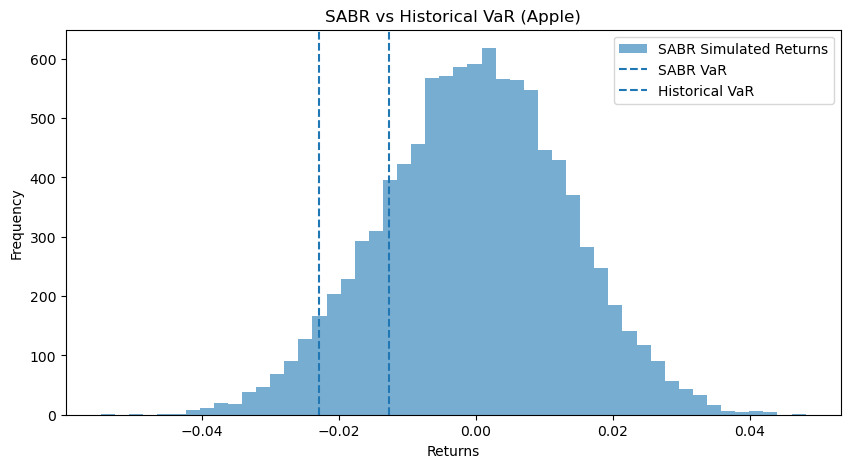

In [2]:

# ✅ STEP 1: LIBRARIES IMPORT
import numpy as np                  # numerical calculations fast karne ke liye (vectorization)
import pandas as pd                 # structured data handle karne ke liye (DataFrame)
import yfinance as yf               # Yahoo Finance se live stock data lene ke liye
import matplotlib.pyplot as plt     # graphs plot karne ke liye (visual analysis)

# ✅ STEP 2: LIVE DATA DOWNLOAD (APPLE - LAST 2 MONTH)

ticker = "AAPL"                     # Apple stock ka symbol

data = yf.download(ticker, period="2mo", interval="1d")  
# last 2 months ka daily data download kar rahe hain (real market data)

data = data[['Close']]              
# sirf closing price le rahe hain (VaR aur returns ke liye enough hota hai)

data['Returns'] = data['Close'].pct_change()  
# daily returns nikal rahe hain (price change % me)

data.dropna(inplace=True)           
# NaN (missing values) remove kar rahe hain taaki calculations sahi 


# ============================================================
# ✅ STEP 3: HISTORICAL VOLATILITY (REAL MARKET)
# ============================================================

hist_vol = data['Returns'].std() * np.sqrt(252)  
# std dev of returns → annualized volatility (252 trading days assume)

print("Historical Volatility:", hist_vol)  
# real market volatility print kar rahe hain (benchmark ke liye)


# ============================================================
# ✅ STEP 4: SABR MODEL PARAMETERS
# ============================================================

alpha = hist_vol                    # initial volatility (realistic banane ke liye historical vol use kiya)
beta  = 1.0                         # equity market → lognormal assumption (Black-Scholes jaisa)
rho   = -0.4                        # price aur volatility ka negative relation (market crash → vol spike)
nu    = 0.6                         # volatility of volatility (vol kitni fast change hoti hai)

S0 = float(data['Close'].iloc[-1])  
# latest price ko scalar float bana rahe hain (important: error avoid karne ke liye)


# ============================================================
# ✅ STEP 5: SABR MONTE CARLO SIMULATION
# ============================================================

n_sim = 10000                       # number of simulations (jitna zyada utna accurate)
T = 1/252                           # 1-day horizon (VaR ke liye)
dt = T                              # time step

sim_prices = []                     # future simulated prices store karne ke liye empty list

for i in range(n_sim):              # loop through each simulation

    z1 = np.random.normal()         # random shock for price (Brownian motion)
    z2 = np.random.normal()         # random shock for volatility

    w1 = z1                         # price ka direct shock
    w2 = rho*z1 + np.sqrt(1 - rho**2)*z2  
    # correlation apply kar rahe hain (price & vol linked ho gaye)

    sigma_t = alpha * np.exp(nu * np.sqrt(dt) * w2)  
    # SABR volatility evolve ho rahi hai (random + dynamic)

    S_t = S0 * np.exp(sigma_t * np.sqrt(dt) * w1 - 0.5 * sigma_t**2 * dt)  
    # future price simulate kar rahe hain (GBM + stochastic vol)

    sim_prices.append(S_t)          
    # har simulation ka result list me store kar rahe hain


sim_prices = np.array(sim_prices, dtype=float)  
# list ko numpy array me convert kar rahe hain (fast calculations ke liye)


# ============================================================
# ✅ STEP 6: SIMULATED RETURNS
# ============================================================

sim_returns = (sim_prices - S0) / S0  
# simulated price se returns nikal rahe hain (% terms me)


# ============================================================
# ✅ STEP 7: VaR CALCULATION (MODEL vs REAL)
# ============================================================

confidence = 0.95                   # 95% confidence level

var_sabr = np.percentile(sim_returns, 5)  
# SABR model VaR (worst 5% scenario)

var_hist = np.percentile(data['Returns'], 5)  
# historical VaR (past data se)

print("SABR VaR:", var_sabr)        
# model based risk

print("Historical VaR:", var_hist)  
# real market past risk


# ============================================================
# ✅ STEP 8: IMPLIED VOLATILITY (MODEL OUTPUT)
# ============================================================

implied_vol = np.std(sim_returns) * np.sqrt(252)  
# simulated returns se volatility nikal rahe hain (model implied vol)

print("Model Implied Volatility:", implied_vol)  
# model vs historical comparison ke liye


# ============================================================
# ✅ STEP 9: VISUALIZATION
# ============================================================

plt.figure(figsize=(10,5))          
# graph ka size set kar rahe hain

plt.hist(sim_returns, bins=50, alpha=0.6, label="SABR Simulated Returns")  
# simulated returns ka distribution (histogram)

plt.axvline(var_sabr, linestyle='dashed', label="SABR VaR")  
# SABR VaR ko vertical line se show kar rahe hain

plt.axvline(var_hist, linestyle='dashed', label="Historical VaR")  
# historical VaR bhi show kar rahe hain (comparison ke liye)

plt.legend()                        
# labels show karne ke liye

plt.title("SABR vs Historical VaR (Apple)")  
# graph ka title

plt.xlabel("Returns")               
# x-axis → returns

plt.ylabel("Frequency")             
# y-axis → frequency (kitni baar value aayi)

plt.show()                          
# final graph display

✅ STEP 2: Data Download
yf.download("AAPL", period="2mo")

👉 Apple ka last 2 months ka real data

pct_change()

👉 Daily returns → VaR aur volatility ke liye base

✅ STEP 3: Historical Volatility
std() * sqrt(252)

👉 Annualized volatility

📌 Meaning:

Real market me Apple kitna volatile hai

✅ STEP 4: SABR Parameters

👉 Smart trick:

alpha = historical vol (realistic start)
beta = 1 (equity)
rho = negative (market crash → vol spike)
nu = vol ka volatility
✅ STEP 5: SABR Simulation 🔥

Core logic:

1️⃣ Random shocks
z1, z2
2️⃣ Correlation
w2 = rho*z1 + sqrt(...)

👉 Price & vol linked ho gaye

3️⃣ Volatility evolve
sigma_t = alpha * exp(...)

👉 Volatility random hai (SABR magic)

4️⃣ Price evolve
S_t = S0 * exp(...)

👉 Future price generate

✅ STEP 7: VaR Comparison
np.percentile(..., 5)

👉 Worst 5% scenario

Type	Meaning
Historical VaR	Real past data
SABR VaR	Model-based future
✅ STEP 8: Implied Volatility
std(sim_returns)

👉 Model se nikla hua volatility

📌 Compare:

Historical Vol vs Model IV
🔷 📊 Visualization (Concept)
🔷 🔥 Output Interpretation (MOST IMPORTANT)
1️⃣ VaR Compare
Case	Meaning
SABR VaR > Historical	Model zyada risk dikha raha
SABR VaR < Historical	Model underestimating

👉 Trading edge:

Agar model zyada risk dikha raha → options expensive ho sakte hain

2️⃣ Volatility Compare
Case	Meaning
IV > Historical	Market fear
IV < Historical	Market calm
3️⃣ Distribution Shape

👉 SABR:

fat tails
skewness

👉 Real market:

similar behavior
🔷 💹 Trading Insight (Tumhare level ka)

Tum isse:

✅ Tail risk detect kar sakte ho
✅ Vol mispricing pakad sakte ho
✅ Skew trading kar sakte ho
✅ VaR-based position sizing kar sakte ho

🔷 🚀 Next Level (Highly Recommended)

Agar tum next step chahte ho:

👉 
Real options chain se SABR calibration
👉 
Strike-wise IV smile banana
👉 
Greeks + SABR combine

Bolna:

"next level sabr calibration"

Main tumhe hedge fund level model bana ke dunga 🔥